In [2]:
!pip install scikit-learn pandas matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load the UCI Adult dataset directly from the web
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

df = pd.read_csv(url, header=None, names=columns, na_values=' ?', skipinitialspace=True)

print(df.shape)
df.head()

(32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Drop rows with missing values
df = df.dropna()

# Strip whitespace from string columns
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

# Encode the outcome variable as 0/1
df['income'] = (df['income'] == '>50K').astype(int)

print("Class balance:")
print(df['income'].value_counts())

Class balance:
income
0    24720
1     7841
Name: count, dtype: int64


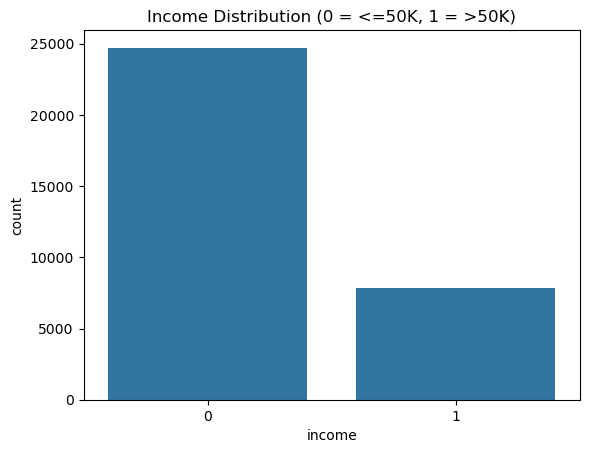

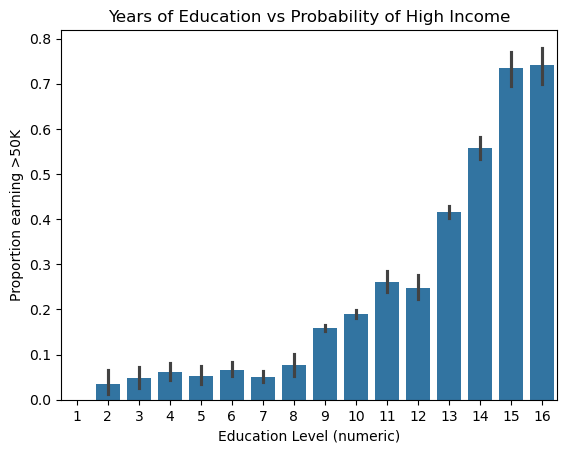

In [6]:
# Plot income distribution
sns.countplot(x='income', data=df)
plt.title('Income Distribution (0 = <=50K, 1 = >50K)')
plt.show()

# Education vs income
sns.barplot(x='education_num', y='income', data=df)
plt.title('Years of Education vs Probability of High Income')
plt.xlabel('Education Level (numeric)')
plt.ylabel('Proportion earning >50K')
plt.show()

In [7]:
# Select features to use
features = ['age', 'education_num', 'hours_per_week', 'capital_gain',
            'capital_loss', 'sex', 'race', 'workclass', 'marital_status', 'occupation']

df_model = df[features + ['income']].copy()

# Encode categorical variables
le = LabelEncoder()
cat_cols = ['sex', 'race', 'workclass', 'marital_status', 'occupation']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Split into features (X) and outcome (y)
X = df_model.drop('income', axis=1)
y = df_model['income']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (26048, 10), Test set: (6513, 10)


In [8]:
# Fit logistic regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Evaluate
y_pred_lr = lr.predict(X_test)
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.3f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.84      0.93      0.89      4942
           1       0.68      0.46      0.55      1571

    accuracy                           0.82      6513
   macro avg       0.76      0.70      0.72      6513
weighted avg       0.81      0.82      0.80      6513

AUC-ROC: 0.843


In [9]:
# Fit random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4942
           1       0.72      0.63      0.67      1571

    accuracy                           0.85      6513
   macro avg       0.80      0.78      0.79      6513
weighted avg       0.85      0.85      0.85      6513

AUC-ROC: 0.898


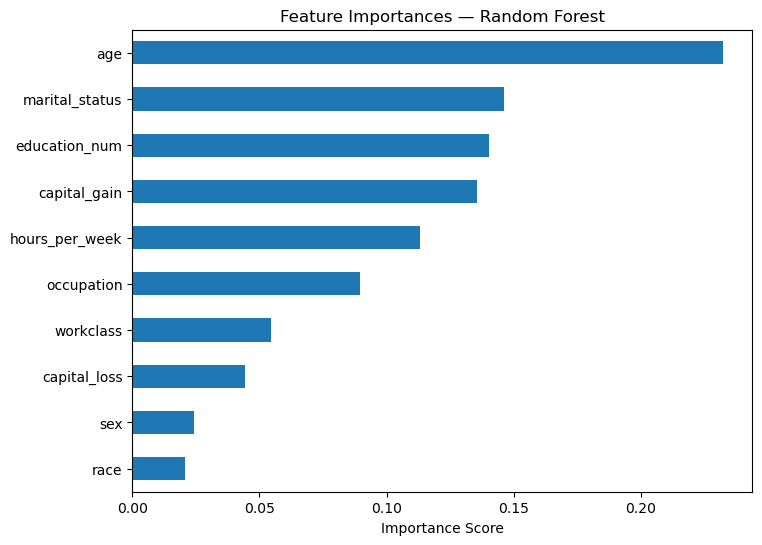

In [10]:
# Which features matter most?
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title('Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.show()